In [1]:
## Input Cell

from pyextremes import EVA
import pandas as pd
import numpy as np
from datetime import datetime
import os
import matplotlib.pyplot as plt
from scipy import stats
import xarray as xr

RP = [1, 2, 5, 10, 20, 50, 100]

surge = pd.read_csv(os.path.join('..', 'data', 'water_levels', 'surge_quinta_dailymax_1950_2024.csv'), index_col=0, parse_dates=True)

surge = surge.squeeze("columns").dropna().sort_index()
surge.name = "surge"



## Return Period Analysis

In [10]:

# (a) peaks-over-threshold, GPD, 3-day declustering
thr = surge.quantile(0.99)
eva_pot = EVA(surge)
eva_pot.get_extremes(method='POT', threshold=thr, r='72h')
eva_pot.fit_model()
pot = eva_pot.get_summary(return_period=RP, alpha=0.95)

# (b) block maxima (annual), GEV
eva_bm = EVA(surge)
eva_bm.get_extremes(method='BM', block_size='365.2425D')
eva_bm.fit_model()
bm = eva_bm.get_summary(return_period=RP, alpha=0.95)

res = pd.concat({'POT_GPD': pot, 'BM_GEV': bm}, axis=1).round(3)
print(res)

fig = eva_pot.plot_diagnostic(alpha=0.95)

fig = eva_bm.plot_diagnostic(alpha=0.95)

                   POT_GPD                         BM_GEV                  
              return value lower ci upper ci return value lower ci upper ci
return period                                                              
1.0                  0.117    0.117    0.119         -inf      NaN      NaN
2.0                  0.123    0.122    0.126        0.116    0.114    0.119
5.0                  0.130    0.128    0.133        0.127    0.123    0.130
10.0                 0.135    0.131    0.138        0.134    0.129    0.138
20.0                 0.139    0.133    0.142        0.140    0.134    0.145
50.0                 0.143    0.135    0.148        0.149    0.142    0.155
100.0                0.146    0.137    0.152        0.155    0.147    0.163


c:\Users\mscha\miniconda3\envs\quintaplaya\Lib\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


## 2. Correlation between waves and surge

It is not correlated!

In [ ]:
"""Correlation between daily-max wave conditions (ERA5) and daily-max storm
surge (GTSM-ERA5) at Quinta Playa.

Outputs: correlation table (Pearson + Spearman, by season and by direction
sector), lagged cross-correlation, conditional exceedance of surge given
high waves, and a figure. Adjust the column names at the top to match your
ERA5 file.
"""

WAVES = os.path.join('..', 'data', 'waves', 'daily_max_hs.csv')      # columns: date, Hs, Tp, dir (dir = coming-from, deg N)
SURGE = os.path.join('..', 'data', 'water_levels', 'surge_quinta_dailymax_1950_2024.csv')
WCOL  = {'date': 'date', 'Hs': 'Hs', 'Tp': 'Tp', 'dir': 'dir'}
SEASONS = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
DIR_BINS = [(150, 180, 'S–SSE'), (180, 210, 'S–SSW'), (210, 240, 'SW'), (240, 270, 'WSW')]
LAGS = range(-3, 4)                            # days; positive = surge lags waves

# ---------------------------------------------------------------- load & align
w = pd.read_csv(WAVES, parse_dates=[WCOL['date']]).rename(columns={v: k for k, v in WCOL.items()})
w['date'] = pd.to_datetime(w['date']).dt.tz_localize(None).dt.normalize()
w = w.set_index('date')[['Hs_max', 'Tp', 'MeanDir']]
rename_dict = {'Hs_max': 'Hs', 'MeanDir': 'dir'}
w = w.rename(columns=rename_dict)

s = pd.read_csv(SURGE, index_col=0, parse_dates=True).iloc[:, 0].rename('surge')
s.index = pd.to_datetime(s.index).tz_localize(None).normalize()

df = w.join(s, how='inner').dropna()
df['P'] = 1025 * 9.81**2 / (64 * np.pi) * df.Hs**2 * df.Tp / 1000   # wave power, kW/m
df['month'] = df.index.month
print(f'{len(df)} common days, {df.index.min().date()} to {df.index.max().date()}')

# ---------------------------------------------------------------- correlations
def corr_table(d):
    rows = {}
    for v in ['Hs', 'Tp', 'P']:
        rows[v] = {'pearson': stats.pearsonr(d[v], d.surge)[0],
                   'spearman': stats.spearmanr(d[v], d.surge)[0], 'n': len(d)}
    # direction: circular–linear correlation (Mardia)
    th = np.radians(d['dir']); y = d.surge
    rc, rs = stats.pearsonr(np.cos(th), y)[0], stats.pearsonr(np.sin(th), y)[0]
    rcs = stats.pearsonr(np.cos(th), np.sin(th))[0]
    rows['dir'] = {'pearson': np.sqrt((rc**2 + rs**2 - 2*rc*rs*rcs) / (1 - rcs**2)),
                   'spearman': np.nan, 'n': len(d)}
    return pd.DataFrame(rows).T

tabs = {'all': corr_table(df)}
for name, months in SEASONS.items():
    tabs[name] = corr_table(df[df.month.isin(months)])
for lo, hi, name in DIR_BINS:
    sub = df[(df['dir'] >= lo) & (df['dir'] < hi)]
    if len(sub) > 30:
        tabs[f'dir {name}'] = corr_table(sub)
corr = pd.concat(tabs, names=['subset', 'variable']).round(3)
print(corr.to_string())

# ---------------------------------------------------------------- lagged cross-correlation (Hs -> surge)
lag = pd.Series({k: df.Hs.corr(df.surge.shift(-k)) for k in LAGS}, name='r').round(3)
lag.index.name = 'lag_days (surge lags waves)'
print('\nlagged correlation Hs vs surge:\n', lag.to_string())

# ---------------------------------------------------------------- conditional exceedance
q = 0.95
hs95, sg95 = df.Hs.quantile(q), df.surge.quantile(q)
p_cond = ((df.Hs > hs95) & (df.surge > sg95)).sum() / (df.Hs > hs95).sum()
print(f'\nP(surge > p95 | Hs > p95) = {p_cond:.2f}  (independent: {1-q:.2f})')
top = df.nlargest(20, 'surge')[['surge', 'Hs', 'Tp', 'dir']]
print('\n20 largest surge days:\n', top.round(2).to_string())



8536 common days, 2000-01-01 to 2024-12-25
                    pearson  spearman       n
subset    variable                           
all       Hs          0.111     0.123  8536.0
          Tp          0.047     0.054  8536.0
          P           0.093     0.114  8536.0
          dir         0.062       NaN  8536.0
DJF       Hs          0.136     0.146  1975.0
          Tp          0.013     0.027  1975.0
          P           0.096     0.116  1975.0
          dir         0.047       NaN  1975.0
MAM       Hs         -0.014    -0.003  2274.0
          Tp         -0.014    -0.013  2274.0
          P          -0.012    -0.011  2274.0
          dir         0.021       NaN  2274.0
JJA       Hs         -0.014    -0.004  2104.0
          Tp          0.028     0.008  2104.0
          P          -0.005     0.006  2104.0
          dir         0.063       NaN  2104.0
SON       Hs          0.042     0.050  2183.0
          Tp         -0.011     0.007  2183.0
          P           0.031     0.031

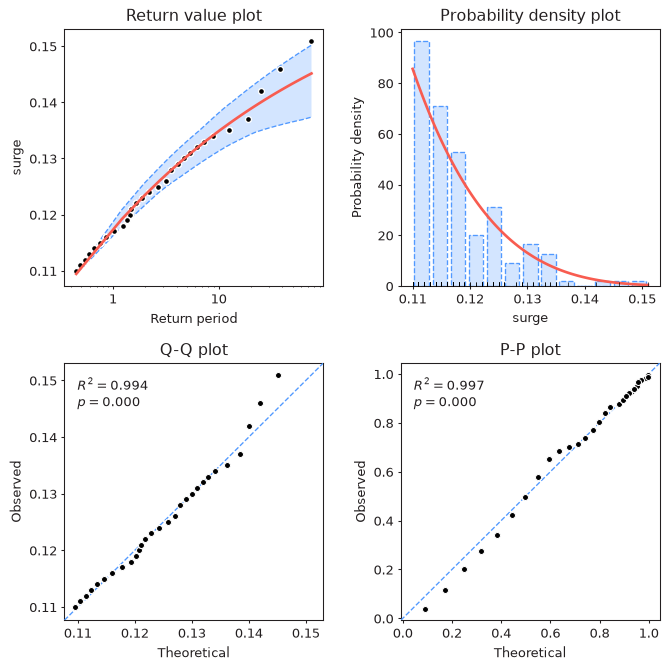

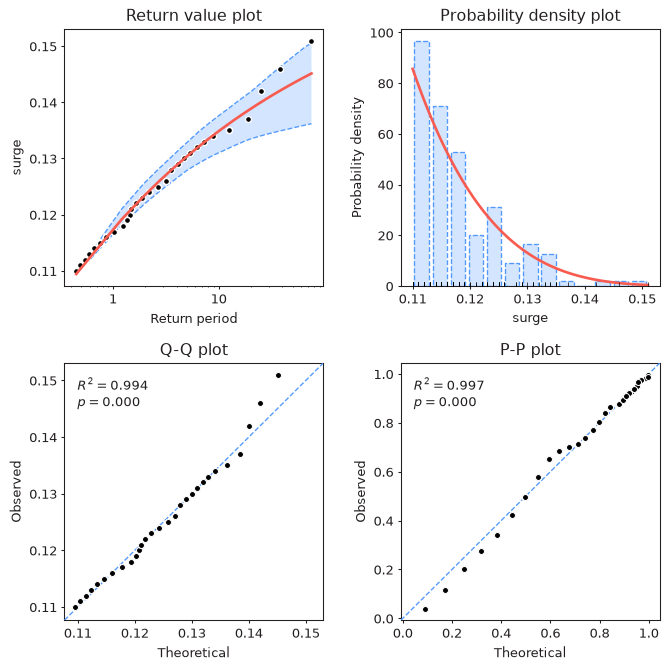

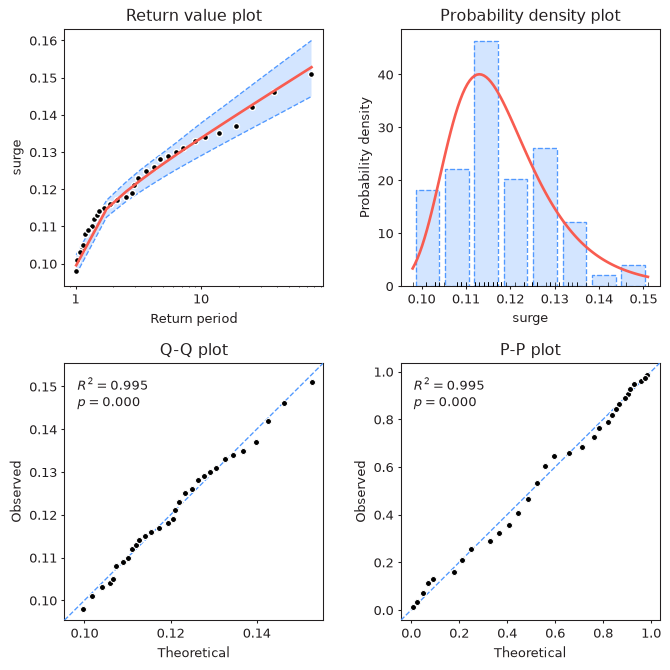

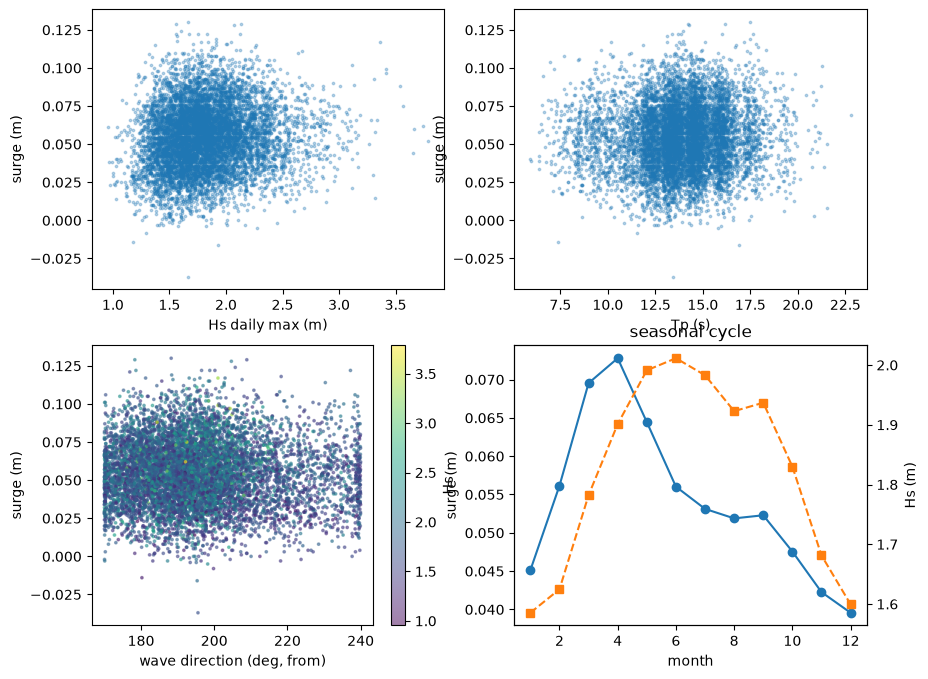

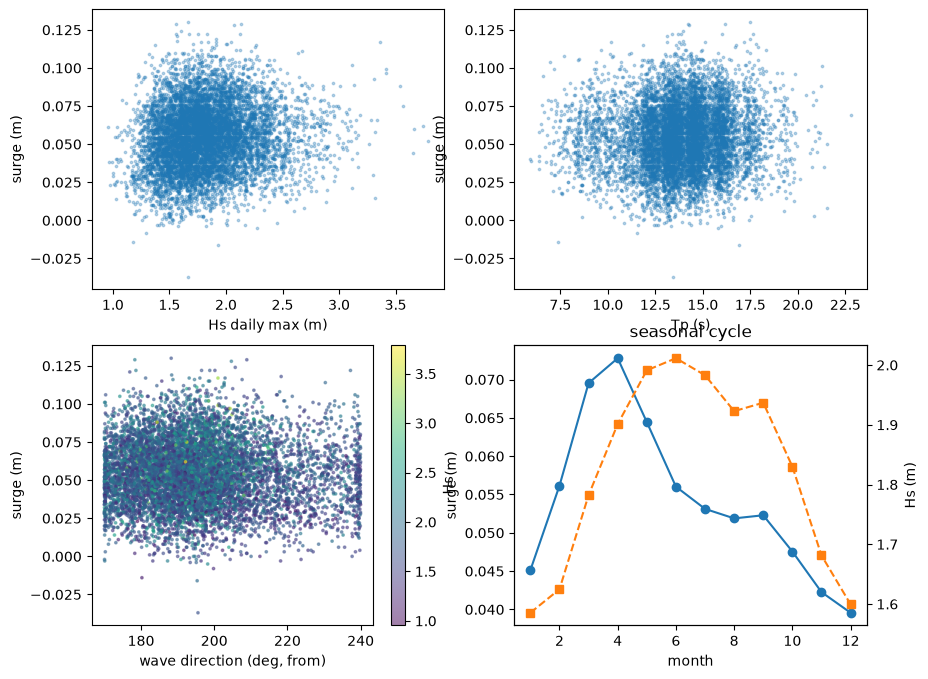

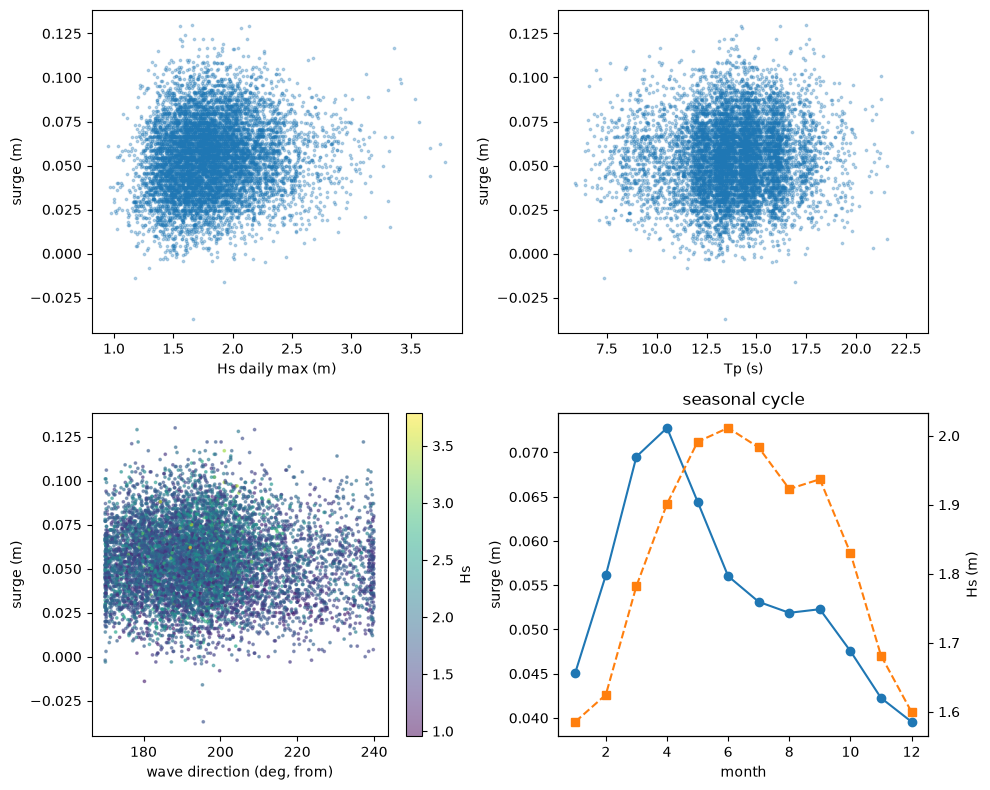

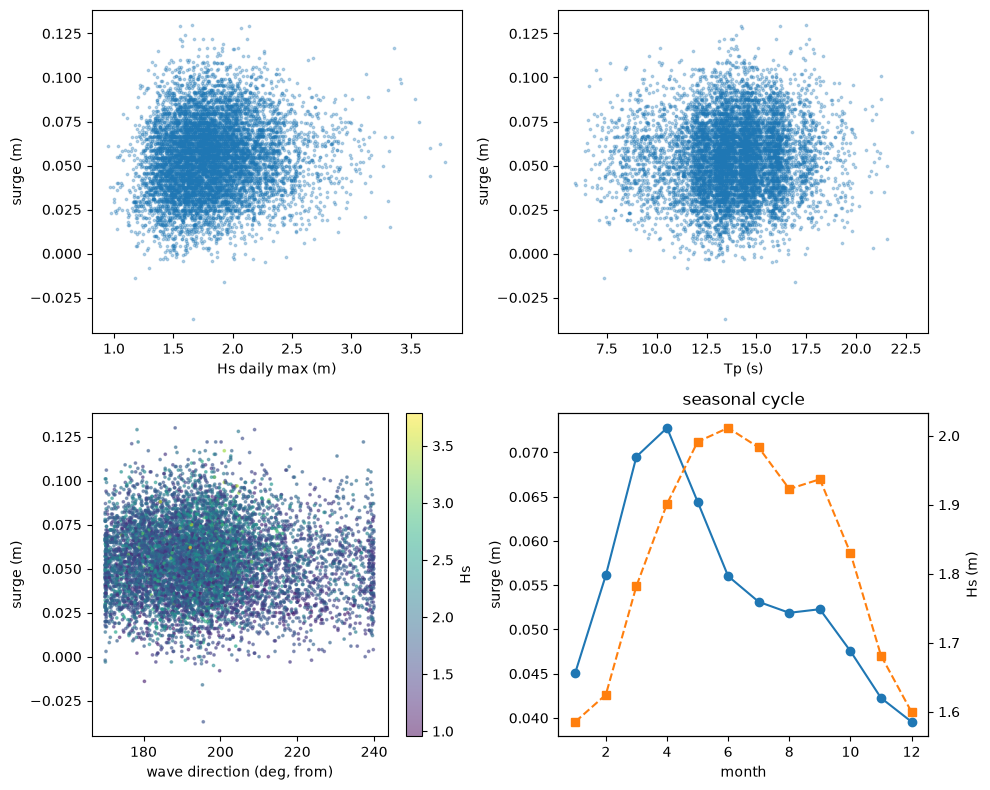

In [17]:
# ---------------------------------------------------------------- figure
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax[0, 0].scatter(df.Hs, df.surge, s=3, alpha=.3); ax[0, 0].set_xlabel('Hs daily max (m)'); ax[0, 0].set_ylabel('surge daily max (m)')
ax[0, 1].scatter(df.Tp, df.surge, s=3, alpha=.3); ax[0, 1].set_xlabel('Tp (s)')
sc = ax[1, 0].scatter(df['dir'], df.surge, c=df.Hs, s=3, alpha=.5, cmap='viridis')
ax[1, 0].set_xlabel('wave direction (deg, from)'); ax[1, 0].set_ylabel('surge (m)'); plt.colorbar(sc, ax=ax[1, 0], label='Hs')
m = df.groupby('month')[['surge', 'Hs']].mean()
ax[1, 1].plot(m.index, m.surge, 'o-', label='mean daily-max surge'); ax[1, 1].set_ylabel('surge (m)')
ax2 = ax[1, 1].twinx(); ax2.plot(m.index, m.Hs, 's--', color='C1', label='mean daily-max Hs'); ax2.set_ylabel('Hs (m)')
ax[1, 1].set_xlabel('month'); ax[1, 1].set_title('seasonal cycle')
for a in ax[0]: a.set_ylabel('surge (m)')
fig.tight_layout()
plt.show()


## 3. Monthly Stats

In [19]:
m = surge.groupby(surge.index.month)
monthly = pd.DataFrame({'median': m.median(), 'mean': m.mean(),
                        'p10': m.quantile(.1), 'p90': m.quantile(.9),
                        'p99': m.quantile(.99), 'max': m.max()}).round(3)
monthly.index.name = 'month'
print(monthly)

monthly['median'].plot(marker='o', ylabel='daily-max surge (m)', xlabel='month')
plt.fill_between(monthly.index, monthly.p10, monthly.p90, alpha=.3)

       median   mean    p10    p90    p99    max
month                                           
1       0.044  0.045  0.019  0.072  0.101  0.133
2       0.057  0.057  0.031  0.083  0.107  0.124
3       0.069  0.069  0.045  0.094  0.117  0.135
4       0.073  0.073  0.049  0.098  0.119  0.151
5       0.065  0.066  0.041  0.092  0.114  0.125
6       0.056  0.057  0.032  0.083  0.108  0.142
7       0.055  0.055  0.030  0.083  0.106  0.146
8       0.054  0.055  0.029  0.080  0.103  0.131
9       0.054  0.054  0.030  0.079  0.098  0.137
10      0.048  0.049  0.025  0.073  0.093  0.126
11      0.041  0.042  0.018  0.067  0.087  0.129
12      0.040  0.041  0.014  0.067  0.096  0.115


## Correlation with ENSO

In [2]:
import netCDF4

In [ ]:

m = surge.resample('MS').mean()
m = m - m.groupby(m.index.month).transform('mean')                       # remove seasonal cycle
t = np.arange(len(m)); m = m - np.polyval(np.polyfit(t, m.values, 1), t)   # remove trend

ds = xr.open_dataset(os.path.join('..', 'data', 'enso', 'nina1.anom.nc'))
print(ds)                                                                # check variable name
nino12 = ds[list(ds.data_vars)[0]].to_series()
nino12 = nino12.where(nino12 > -90)                                      # PSL missing value is -99.99
nino12.index = pd.to_datetime(nino12.index).to_period('M').to_timestamp()

df = pd.concat([m.rename('surge'), nino12.rename('nino12')], axis=1).dropna()
print(f'{len(df)} months, {df.index[0]:%Y-%m} to {df.index[-1]:%Y-%m}\n')

r = {lag: df.surge.corr(df.nino12.shift(lag)) for lag in range(-3, 7)}
best = max(r, key=lambda k: abs(r[k]))
print(f'nino12: r(lag 0) = {r[0]:+.2f}   strongest r = {r[best]:+.2f} at lag {best} mo (ENSO leading)')

phase = pd.cut(df.nino12, [-9, -0.5, 0.5, 9], labels=['cold', 'neutral', 'warm'])
print('\nmean surge anomaly by Niño 1+2 phase (cm):\n', (df.surge.groupby(phase).mean() * 100).round(2))

<xarray.Dataset> Size: 11kB
Dimensions:  (time: 944)
Coordinates:
  * time     (time) datetime64[ns] 8kB 1948-01-01 1948-02-01 ... 2026-08-01
Data variables:
    value    (time) float32 4kB ...
900 months, 1950-01 to 2024-12

nino12: r(lag 0) = +0.65   strongest r = +0.65 at lag 0 mo (ENSO leading)

mean surge anomaly by Niño 1+2 phase (cm):
 nino12
cold      -0.46
neutral   -0.01
warm       1.08
Name: surge, dtype: float64


C:\Users\mscha\AppData\Local\Temp\ipykernel_44964\4144849806.py:11: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat([m.rename('surge'), nino12.rename('nino12')], axis=1).dropna()
